In [1]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import json


# Cosmetics:
import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

### Load NLO reference cross-sections

In [2]:
# Reference cross-sections from:
# https://twiki.cern.ch/twiki/bin/view/LHCPhysics/SUSYCrossSections13TeVx1x1wino
# and
# https://twiki.cern.ch/twiki/bin/view/LHCPhysics/SUSYCrossSections13TeVn2x1wino
xsecs_c1c1 = np.genfromtxt('xsec_13TeV_pp2chgchg_fb.csv',delimiter=',',names=True)
xsecs_c1n1 = np.genfromtxt('xsec_13TeV_pp2chgn1_fb.csv',delimiter=',',names=True)

def xsc1c1(mLLP : float) -> float:
    """
    Interpolate chargino-chargino cross-sections
    """
    xs = np.interp(mLLP, xsecs_c1c1['mass'], xsecs_c1c1['xsec'])
    return float(xs)

def xsc1n1(mLLP : float) -> float:
    """
    Interpolate chargino-neutralino cross-sections
    """
    
    xs = np.interp(mLLP, xsecs_c1n1['mass'], xsecs_c1n1['xsec'])
    return float(xs)

### Load ATLAS official exclusion curve

In [3]:
atlas_official = list(np.genfromtxt('../ATLAS_data/official_exclusion.txt',delimiter=';'))
atlas_official = sorted(atlas_official, key = lambda x: x[1])
atlas_official = np.array(atlas_official)

### Create dataframe with all results

In [4]:
# Load combined json file (created with collectData.py)
dfs = {}
for jsonFile in ['C1C1_effs.json','C1N1_effs.json']:
    with open(jsonFile, 'r') as f:
        data = json.load(f)

    columns = list(data[0].keys())
    columns.remove('Efficiencies')
    # Expand efficiencies for all lifetimes
    df = pd.json_normalize(
        data,
        record_path="Efficiencies",  # list to explode
        meta=columns
    )
    # Add width column    
    df['width_GeV'] = 6.582e-16/df['tau_ns']

    # Keep only the necessary information:
    # mLLP = LLP mass (GeV)
    # tau0_ns = lifetime used for event generation (ns)
    # tau_ns = lifetime used for reweights (ns)
    # EWK SR = efficiency for the EWK signal region
    # EWK SR Error = MC errior for the efficiency    
    df = df[['mLLP','width_GeV','tau0_ns','tau_ns','EWK SR', 'EWK SR Error']]
    
    dfs[jsonFile] = df

### For each (mLLP,tau) keep only the entry with tau/tau0 closest to 1

In [5]:
for jsonFile,df in dfs.items():
    keep_indices = []
    for group,df_g in df.groupby(['mLLP','tau_ns']):
        imin = np.argmin(np.abs(1.0-df_g['tau_ns']/df_g['tau0_ns']))
        ii = df_g.index.to_list()[imin]
        keep_indices.append(ii)
    dfs[jsonFile] = df[df.index.isin(keep_indices)]

### Create a combined dataset for C1C1+C1N1

In [6]:
df_comb = pd.merge(dfs['C1C1_effs.json'],dfs['C1N1_effs.json'],on=['mLLP','tau_ns','tau0_ns'],suffixes=['_c1c1','_c1n1'])

# Get the production cross-sections for each process
df_comb['xsec_c1c1'] = df_comb['mLLP'].map(xsc1c1)
df_comb['xsec_c1n1'] = df_comb['mLLP'].map(xsc1n1)

# Compute the visible cross-section given the efficiencies for each process
df_comb['xsec_vis'] = df_comb['xsec_c1c1']*df_comb['EWK SR_c1c1']+df_comb['xsec_c1n1']*df_comb['EWK SR_c1n1']

# Compute the r-value, r = sigma_visible/sigma_upperLimit
# Model-independent upper limit on the signal cross-section (from https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/SUSY-2018-19/tab_08.png)
sigma_UL = 0.037
df_comb['r'] = df_comb['xsec_vis']/sigma_UL

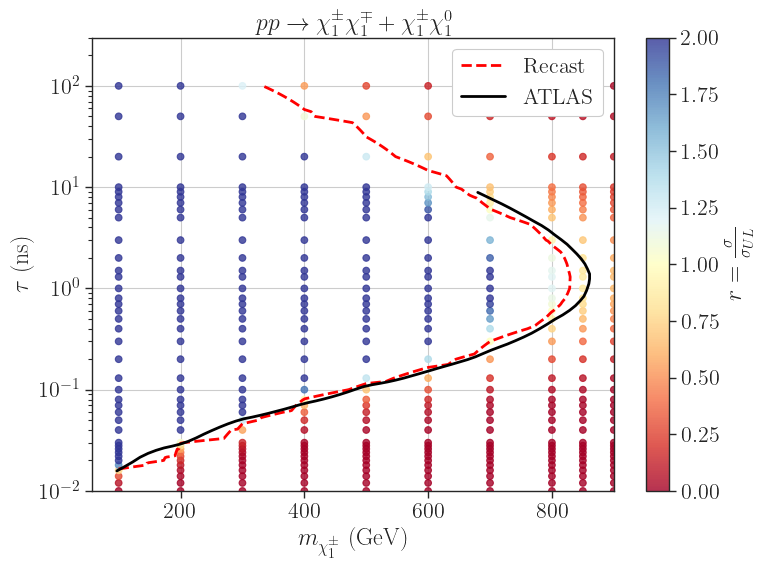

In [7]:
plt.figure(figsize=(8,6))

x = df_comb['mLLP']
y = df_comb['tau_ns']
z = df_comb['r']

plt.scatter(x,y,c=z,cmap=cm,vmin=0,vmax=2.0,alpha=0.8)
    
plt.yscale('log')
plt.ylabel(r'$\tau$ (ns)')
plt.xlabel(r'$m_{\chi_1^\pm}$ (GeV)')
plt.colorbar(label=r'$r = \frac{\sigma}{\sigma_{UL}}$')

plt.title(r'$p p \to \chi_1^\pm \chi_1^\mp + \chi_1^\pm \chi_1^0$')

grid_x, grid_y = np.linspace(x.min(), x.max(), 2000), np.logspace(np.log(y.min()), np.log(y.max()), 2000)
grid_x, grid_y = np.meshgrid(grid_x, grid_y)
grid_z = griddata((x, y), z, (grid_x, grid_y), method='linear')
plt.contour(grid_x, grid_y, grid_z, levels=[1.0], 
            colors='red', linestyles='dashed', linewidths=2.0)
contour_proxy = plt.plot([], [], 
                         color='red', label='Recast',
                         linestyle='dashed', linewidth=2.0)
plt.plot(atlas_official[:,0],atlas_official[:,1],linewidth=2,color='black',label='ATLAS')

plt.legend(loc='upper right',framealpha=1.0)
plt.ylim(1e-2,3e2)
plt.tight_layout()
plt.grid()
plt.savefig('wino_exclusion.png')
plt.show()